# Machine learning: Theory assignment

**Group C**

**Team members:** Pamela Sampaa Afaki, Sarhini Nour, Chiara Nicole Bifulco, Alice Bolard

This notebook follows the questions in the assignment sheet and the supplied notebook. We use the linear regression, bias–variance, data splitting and ridge regression methods from the course. The examples use noisy samples of the function given in the assignment.

Run the cells from top to bottom. The code requires NumPy, Matplotlib and scikit-learn. Random seeds are fixed so the plots can be reproduced.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge

BLUE, RED, GREEN = "#0072B2", "#D55E00", "#009E73"
plt.rcParams.update({"figure.figsize": (7, 4), "font.size": 11})

# 1. Cost functions

Lets focus on linear regression of the form 

$\mathbf{y} \approx f(\mathbf{X}) = \mathbf{X}\mathbf{w_1} + \mathbf{w_0}.$


#### 1.1 What are the rows of $\mathbf{X}$?

Each row is one sample or observation. In a chemistry dataset, this could be one molecule or one material. With $N$ samples and $d$ features, $X$ has shape $N\times d$.

#### 1.2 What are the columns of $\mathbf{X}$?

Each column is one feature used to describe the samples, such as molecular mass or pore volume. The entry $X_{ij}$ is the value of feature $j$ for sample $i$. The target values are stored separately in $y$.

Often, we write the equation above as

$\mathbf{y} \approx \mathbf{\tilde{X}}\mathbf{w}$

#### 1.3 How does $\mathbf{\tilde{X}}$ look like in this case (i.e., how does the shape of the matrix change compared to $\mathbf{X}$)?

We add a column of ones to include the intercept:

$$\tilde X=\begin{pmatrix}1&x_{11}&\cdots&x_{1d}\\ \vdots&\vdots&&\vdots\\1&x_{N1}&\cdots&x_{Nd}\end{pmatrix},\qquad
w=\begin{pmatrix}w_0\\w_1\\\vdots\\w_d\end{pmatrix}.$$

The shape changes from $N\times d$ to $N\times(d+1)$. Multiplying the first column by $w_0$ adds the same intercept to each prediction.

For machine learning, we need a cost function. Two common choices are the mean-squared error (MSE, $\mathcal{L}_2$), and the mean-absolute error (MAE, $\mathcal{L}_1$)

\begin{align}
    \mathcal{L}_2 &=& \frac{1}{N} \sum_{i=1}^N \left(y_i - f(x_i) \right)^2 \\
    \mathcal{L}_1 &=& \frac{1}{N} \sum_{i=1}^N \left|y_i - f(x_i) \right| 
\end{align}

#### 1.4 In the Jupyter notebook, write a Python function that computes these two cost functions given an error term $\boldsymbol{\epsilon} = \mathbf{y} - \mathbf{\tilde{X}}\mathbf{w}$

In [2]:
def mean_squared_error(error_vector):
    error_vector = np.asarray(error_vector, dtype=float)
    return np.mean(error_vector ** 2)

In [3]:
def mean_absolute_error(error_vector):
    error_vector = np.asarray(error_vector, dtype=float)
    return np.mean(np.abs(error_vector))

for error in ([0, 0, 0], [1, 1, 1], [-2, 0, 2]):
    print(f"Errors {error}: MSE = {mean_squared_error(error):.3f}, "
          f"MAE = {mean_absolute_error(error):.3f}")

Errors [0, 0, 0]: MSE = 0.000, MAE = 0.000
Errors [1, 1, 1]: MSE = 1.000, MAE = 1.000
Errors [-2, 0, 2]: MSE = 2.667, MAE = 1.333


Your code should run as follows

```python
mean_squared_error(np.array([0,0,0]))
> returns 0
```

```python
mean_squared_error(np.array([1,1,1]))
> returns 1
```

#### 1.5 What is the shape of these cost functions as a function of the error

In [4]:
x_axis = np.linspace(-10,10,100) # change as you wish for your plot
y_mae = [mean_absolute_error(x) for x in x_axis]
y_mse = [mean_squared_error(x) for x in x_axis]

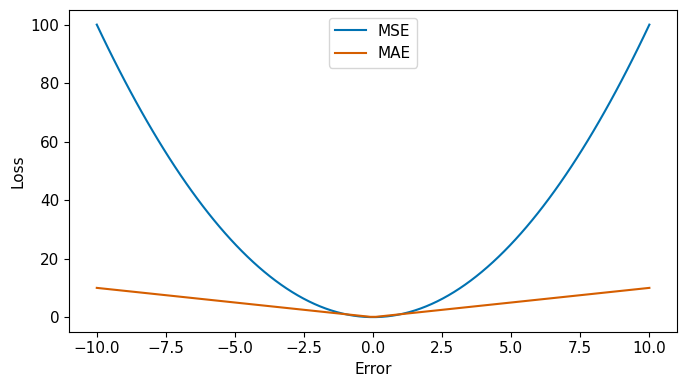

In [5]:
plt.figure()
plt.plot(x_axis, y_mse, color=BLUE, label="MSE")
plt.plot(x_axis, y_mae, color=RED, label="MAE")
plt.xlabel("Error")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

For a single error, MSE is the parabola $\epsilon^2$ and MAE is the V-shaped function $|\epsilon|$. Both have their minimum at zero. MSE becomes much steeper as the error grows.

#### 1.6  Are both loss functions differentiable for all $\boldsymbol{\epsilon}$? What implications does this have for gradient based optimization like gradient descent?

MSE is differentiable everywhere. For one error $\epsilon$, its derivative is $2\epsilon$, including zero.

MAE has derivative $-1$ for negative errors and $+1$ for positive errors. At zero, the two sides do not agree, so it is not differentiable there. Ordinary gradient descent can directly use the MSE gradient. For MAE, we can use subgradient methods, choosing a value in $[-1,1]$ at zero, for example zero.

#### 1.7 Which loss function is more sensitive to outliers and why?

MSE is more sensitive to large outliers because it squares the error, whereas MAE grows linearly. Increasing the error magnitude from 1 to 10 increases the squared loss from 1 to 100, but the absolute loss only from 1 to 10. A large error therefore has much more influence on an MSE fit.

# 2. Regularization

Assume that the columns of $\mathbf{X}$ are linearly independent.
As a refresher of linear algebra, recall when the linear system $\mathbf{X}\mathbf{w} = \mathbf{y}$ has

#### 2.1 One unique solution

Let $X$ have $N$ rows and $d$ columns. A unique exact solution exists when

$$\operatorname{rank}(X)=\operatorname{rank}([X\mid y])=d.$$

The system is consistent and there are no free coefficients. With independent columns, this happens whenever $y$ is in the column space of $X$. If $N=d$, a full-rank square matrix gives a unique solution for every $y$. If $N>d$, only targets in the column space have an exact solution.

#### 2.2 No solution

There is no exact solution when

$$\operatorname{rank}([X\mid y])>\operatorname{rank}(X).$$

Then $y$ is outside the column space of $X$. This is common when there are more observations than features and the measurements contain noise. We can still find a least-squares approximation.

#### 2.3 An infinite number of solutions

There are infinitely many exact solutions when

$$\operatorname{rank}(X)=\operatorname{rank}([X\mid y])<d.$$

The system is consistent, but at least one coefficient is free. This cannot happen under the stated assumption that all columns are independent, since that gives rank $d$. If $d>N$, independent columns are impossible; a consistent system then has infinitely many solutions.

#### 2.4 Give a geometrical interpretation of the matrix Rank (10 bonus point if you use the Manim package)

The rank is the dimension of the space spanned by the columns. Geometrically, it counts how many independent directions their linear combinations can reach. In three dimensions, rank 1 gives a line, rank 2 a plane, and rank 3 the whole space. Rank 0 gives only the origin. An exact solution exists when $y$ lies in this space.

#### 2.5 In general, why can't we solve the linear equation using $\mathbf{y} = \tilde{\mathbf{X}}^{-1}\textbf{w}$? (1 point)

The inverse expression in the question has the variables reversed. If $\tilde X$ were square and invertible, the solution would be $w=\tilde X^{-1}y$.

Usually $\tilde X$ is rectangular because the number of samples differs from the number of coefficients. It then has no ordinary inverse. Even a square matrix is not invertible if its columns are dependent. We therefore minimize the residual error instead of requiring an exact fit.

#### 2.6 Differentiate above formula step by step and show what will we have?

Write $A=\tilde X$ to keep the expressions short. Expanding the squared residual gives

$$L(w)=(y-Aw)^T(y-Aw)
=y^Ty-y^TAw-w^TA^Ty+w^TA^TAw.$$

The two middle terms are equal scalars, so

$$L(w)=y^Ty-2w^TA^Ty+w^TA^TAw.$$

Differentiating each term with respect to $w$, and using the symmetry of $A^TA$, gives

$$\nabla_w(y^Ty)=0,\qquad
\nabla_w(-2w^TA^Ty)=-2A^Ty,\qquad
\nabla_w(w^TA^TAw)=2A^TAw.$$

Therefore,

$$\boxed{\nabla_w L=-2A^T(y-Aw).}$$

#### 2.7 if we want $\| y - \tilde{X} w \|_2^2$ to be minimum, what should the derivative be equal to?

At the minimum, the gradient is zero:

$$-2A^T(y-Aw)=0\quad\Longrightarrow\quad A^TAw=A^Ty.$$

These are the normal equations. If $A$ has independent columns,

$$w=(A^TA)^{-1}A^Ty.$$

The Hessian is $2A^TA$, which is positive semidefinite, so a stationary point is a global minimum. With independent columns it is positive definite and the minimum is unique. If columns are dependent, least-squares predictions are still defined, but the coefficients need not be unique.

#### 2.8 What is the Hat matrix and what does its diagonal values correspond to?

The hat matrix maps the measured targets to fitted targets:

$$\hat y=Hy,\qquad H=A(A^TA)^{-1}A^T.$$

For ordinary least squares with independent columns, it projects $y$ onto the column space of $A$. Its diagonal entries $h_{ii}$ are the leverages. They describe how unusual a sample's features are relative to the training data and how strongly its own target affects its fitted value. A large leverage identifies a potentially influential sample, but does not by itself imply a large residual.

#### 2.9 What is a Williams plot and how does it help in outlier detection?

The question refers to a **Williams plot**. It plots standardized residuals on the vertical axis against leverage $h_{ii}$ on the horizontal axis.

Large absolute standardized residuals indicate samples whose targets are poorly fitted. High leverage indicates unusual feature values. A sample with both may strongly influence the fit. Common warning limits are residuals of $\pm3$ and leverage $h^*=3p/N$, where $p$ is the number of fitted coefficients, including the intercept. These are screening rules, so flagged samples should be checked rather than automatically removed.

Reference for these limits: [Adenosine receptor QSAR study, applicability domain section](https://pmc.ncbi.nlm.nih.gov/articles/PMC5095671/).

#### 2.10 What happens if some columns are linearly dependent? What is the connection to feature selection?

If columns are linearly dependent, $A^TA$ is singular. Several coefficient vectors can give the same predictions, so the ordinary inverse formula cannot be used. If the exact system is consistent, it has infinitely many solutions; otherwise, there is no exact solution, although least-squares minimizers exist.

Feature selection can remove redundant columns and leave a smaller independent set. Strongly correlated features can also make coefficients unstable even without exact dependence. This is related to the caution about correlated descriptors in the interpretability slides. Ridge offers another way to stabilize the fit.

#### 2.11 What will be the new cost function after adding the regularization term?

Following the assignment and ridge slides, we use the sum of squared residuals:

$$L_{\mathrm{ridge}}(w)=\|y-Aw\|_2^2+\lambda\|w\|_2^2,\qquad\lambda\geq0.$$

The added term penalizes large coefficients. At $\lambda=0$ we recover ordinary least squares. Larger $\lambda$ shrinks coefficients more strongly, reducing variance but potentially increasing bias.

This formula penalizes all entries of $w$, including the intercept. In the plotting code, scikit-learn fits the intercept separately and leaves it unpenalized, as in the supplied template. Also, if we used MSE instead of the residual sum, the same fit would require a penalty coefficient $\lambda/N$.

#### 2.12 What will be the new 𝑤 when we differentiate the new cost function and set it to zero.

Differentiating the new loss gives

$$\nabla_w L_{\mathrm{ridge}}=-2A^Ty+2A^TAw+2\lambda w.$$

Setting this equal to zero,

$$ (A^TA+\lambda I)w=A^Ty,$$

so for $\lambda>0$,

$$\boxed{w_{\mathrm{ridge}}=(A^TA+\lambda I)^{-1}A^Ty.}$$

The corresponding prediction matrix is $H_\lambda=A(A^TA+\lambda I)^{-1}A^T$. Unlike the ordinary hat matrix, it is generally not an exact projection.

#### 2.13 Prove that the part of Hat matrix where we want to take the inverse from is always reversible after we introduce the regularization term.

For any nonzero vector $v$ and $\lambda>0$,

$$v^T(A^TA+\lambda I)v
=\|Av\|_2^2+\lambda\|v\|_2^2>0.$$

The first term is nonnegative and the second is strictly positive. Therefore $A^TA+\lambda I$ is positive definite and has no zero eigenvalues, so it is invertible even when columns of $A$ are dependent. At $\lambda=0$, this guarantee disappears.

If the intercept is left unpenalized, the penalty matrix is $D=\operatorname{diag}(0,1,\ldots,1)$ instead of $I$. With a column of ones and at least one sample, $\|Av\|^2+\lambda\sum_{j=1}^d v_j^2$ is still positive for any nonzero $v$: zero slopes leave a nonzero constant prediction if $v_0\ne0$.

#### 2.14  What is the shape of the parabola as a function of $a$?

In [6]:
def parabola(x, a = 1): 
    return a * x ** 2

In [7]:
x_axis_parabola = np.linspace(-10, 10, 100)

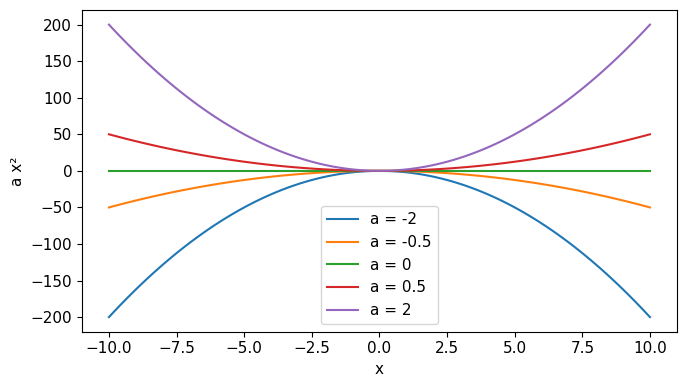

In [8]:
plt.figure()
for a in [-2, -0.5, 0, 0.5, 2]:
    plt.plot(x_axis_parabola, parabola(x_axis_parabola, a), label=f"a = {a}")
plt.xlabel("x")
plt.ylabel("a x²")
plt.legend()
plt.tight_layout()
plt.show()

For $a>0$, the parabola opens upward; for $a<0$, it opens downward. For $a=0$, it is the horizontal line $y=0$. Larger $|a|$ gives a narrower, steeper parabola, while smaller $|a|$ gives a wider, flatter one. All pass through the origin, and their second derivative is $2a$.

Penalizing $a^2$ discourages large curvature in this simple example. For a polynomial with many terms, coefficient shrinkage limits flexibility, although it does not directly minimize curvature.

#### 2.15 Plot the approximation to the function for different order polynomials ($N \in \{1, 2, 16\}$) and with different regularization strength ($\lambda \in \{0, 10^{-3}, 10^{-2}, 1\}$). What do you observe 

In [9]:
def true_function(X):
    return np.cos(1.5 * np.pi * X)

In [10]:
X_test = np.linspace(0, 1, 100) # some grid for us on the x axis

In [11]:
n_samples = 10
degrees = [1, 2, 16]
alphas = [0, 1e-3, 1e-2, 1]

# Fix the seed so every model is compared using the same noisy samples.
rng = np.random.RandomState(0)
X = np.sort(rng.rand(n_samples))
y = true_function(X) + rng.randn(n_samples) * 0.1

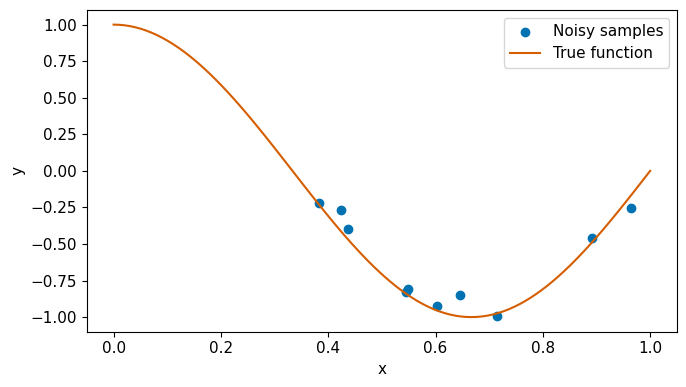

In [12]:
plt.figure()
plt.scatter(X, y, color=BLUE, label="Noisy samples")
plt.plot(X_test, true_function(X_test), color=RED, label="True function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

The following code will fit a polynomial regression, you need to fill the degree

In [13]:
polynomial_features = PolynomialFeatures(degree=2, include_bias=False)
linear_regression = LinearRegression()
pipeline = Pipeline([("polynomial_features", polynomial_features),
                     ("linear_regression", linear_regression)])
pipeline.fit(X[:, np.newaxis], y);

To plot the result, you can use the following code

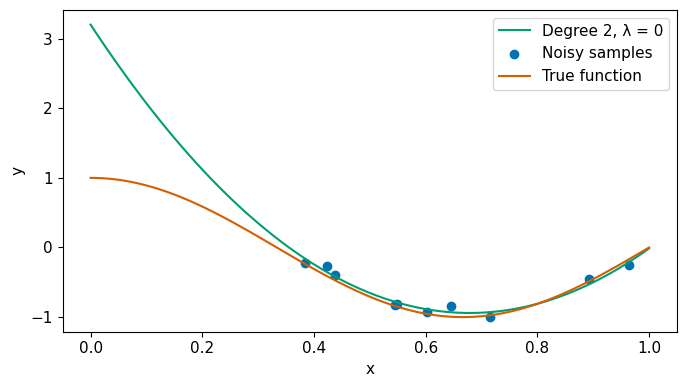

In [14]:
plt.figure()
plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), color=GREEN, label="Degree 2, λ = 0")
plt.scatter(X, y, color=BLUE, label="Noisy samples")
plt.plot(X_test, true_function(X_test), color=RED, label="True function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

Next, we can investigate the effect of the regularization parameter $\lambda$ (function parameter `alpha`), For this, you can use the following code 

In [15]:
polynomial_features = PolynomialFeatures(degree=16, include_bias=False)
ridge_regression = Ridge(alpha=1e-3, solver="svd")
pipeline_ridge = Pipeline([("polynomial_features", polynomial_features),
                           ("ridge_regression", ridge_regression)])
pipeline_ridge.fit(X[:, np.newaxis], y);


def fit_polynomial(x, y, degree, alpha):
    # Use ordinary least squares when the penalty is zero.
    regression = LinearRegression() if alpha == 0 else Ridge(alpha=alpha, solver="svd")
    model = Pipeline([("polynomial_features", PolynomialFeatures(degree=degree, include_bias=False)),
                      ("regression", regression)])
    return model.fit(x[:, np.newaxis], y)

For plotting you can reuse the following code

Degree  λ       Training MSE   MSE against true function on grid
     1  0            0.08443   0.56587
     1  0.001        0.08443   0.566
     1  0.01        0.084431   0.56718
     1  1           0.084719   0.60088
     2  0          0.0035224   0.39173
     2  0.001       0.007466   0.12294
     2  0.01        0.047911   0.19834
     2  1           0.084374   0.6064
    16  0         0.00048352   119.72
    16  0.001       0.003027   0.007624
    16  0.01       0.0067964   0.05903
    16  1           0.058486   0.54036


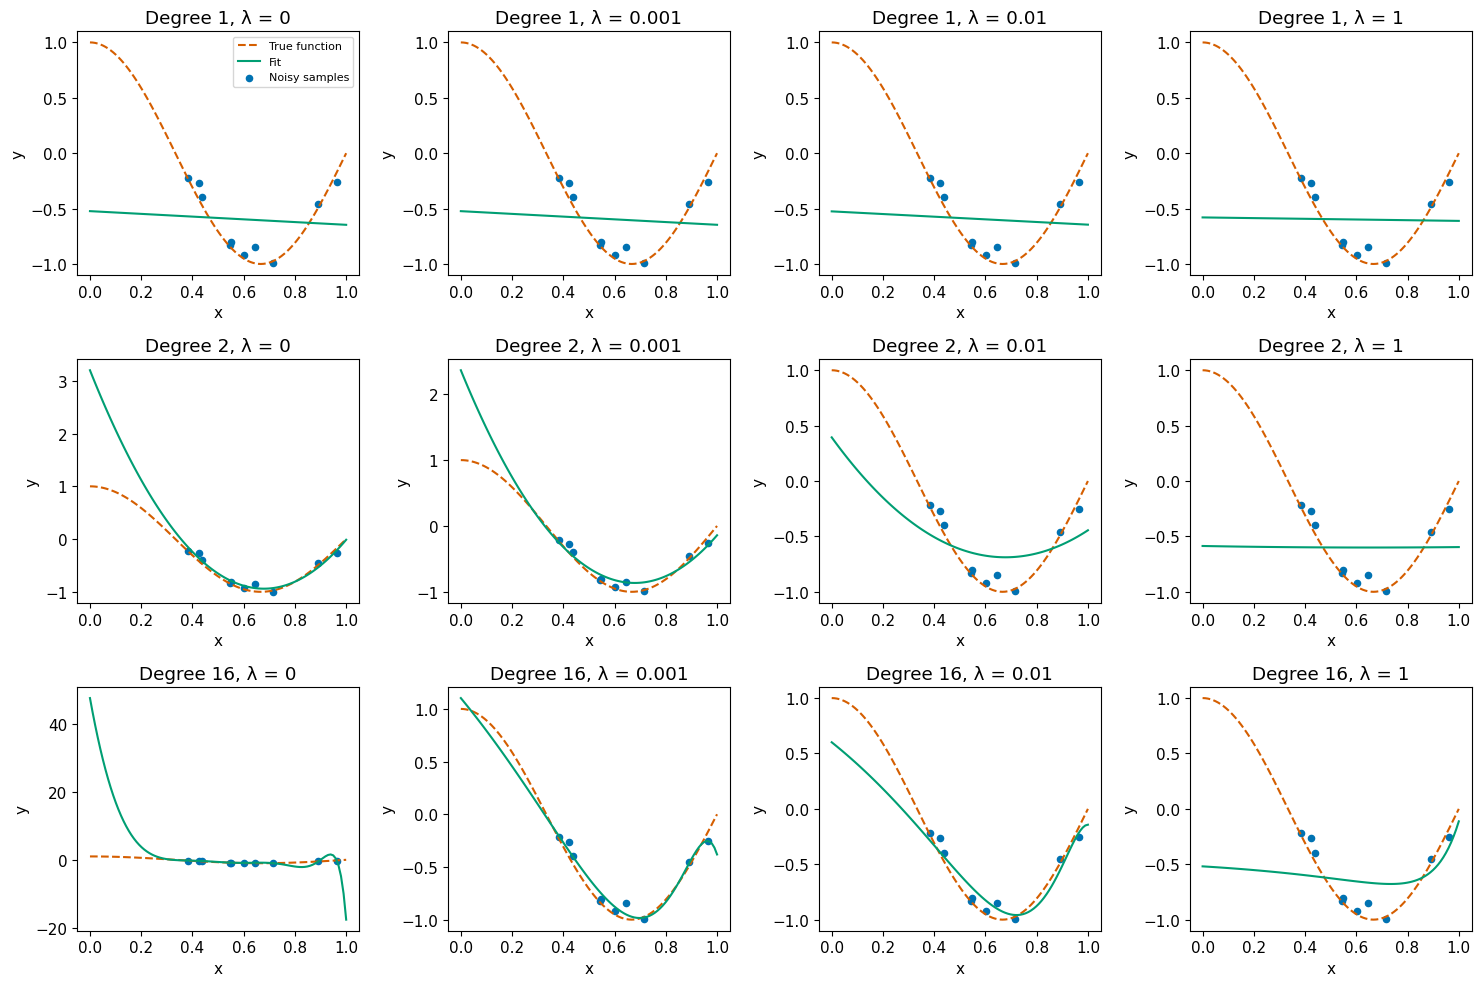

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
print("Degree  λ       Training MSE   MSE against true function on grid")
for row, degree in enumerate(degrees):
    for col, alpha in enumerate(alphas):
        model = fit_polynomial(X, y, degree, alpha)
        prediction = model.predict(X_test[:, np.newaxis])
        ax = axes[row, col]
        ax.plot(X_test, true_function(X_test), color=RED, linestyle="--", label="True function")
        ax.plot(X_test, prediction, color=GREEN, label="Fit")
        ax.scatter(X, y, color=BLUE, s=20, label="Noisy samples")
        ax.set_title(f"Degree {degree}, λ = {alpha:g}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        train_mse = mean_squared_error(y - model.predict(X[:, np.newaxis]))
        grid_mse = mean_squared_error(true_function(X_test) - prediction)
        print(f"{degree:6d}  {alpha:<7g} {train_mse:12.5g}   {grid_mse:.5g}")
axes[0, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

**Results for question 2.15:**

The degree-1 model gives a straight line and misses the curvature of the cosine. Degree 2 follows the broad trend, but cannot reproduce the whole shape. Degree 16 without regularization fits the ten training points almost exactly and shows large excursions, especially near the ends of the interval. Its small training error therefore does not indicate good predictions between or beyond the sampled points.

Adding a small positive penalty makes the degree-16 fit less extreme by shrinking its coefficients. Increasing λ to 1 suppresses the variation more strongly and can miss the true curve. The plots show the bias–variance tradeoff from the course: insufficient flexibility causes underfitting, while excessive flexibility with few samples causes overfitting.

Occam's razor suggests preferring a simpler model when models explain the data similarly well. We should therefore choose degree and λ using validation performance rather than the smallest training error. The grid errors above compare predictions with the known noiseless function for this illustration; they are not an untouched test score, and we do not use them to select hyperparameters.

In this draw, the ten samples cover only x = 0.383 to 0.964. Predictions to the left of this range are therefore extrapolations. For degree 16, the training MSE is about 0.00048 without regularization, but the MSE against the true function across [0, 1] is about 120. With λ = 0.001, these values are about 0.0030 and 0.0076. This illustrates why a slightly worse training fit can give much better predictions. Each panel uses its own vertical scale so that large excursions remain visible.

#### 2.16 What do you observe if you change the number of samples from the function?

We repeat the comparison with 10, 30 and 100 noisy samples below. We keep the noise standard deviation at 0.1 and use the same samples for every model within a panel.

More samples usually constrain the degree-16 fit better, reducing the large oscillations seen with a small dataset. They also make fitting individual noise values less attractive. The degree-1 model still underfits because extra data cannot give a straight line the missing curvature. Ridge generally stabilizes the degree-16 fit, but excessive regularization can still underfit.

The effect depends on sample positions and noise, so a single random draw is an illustration rather than proof of a general trend. With scikit-learn's sum-of-squares loss, keeping $\lambda$ fixed also makes the penalty weaker relative to the data term as the sample count increases.

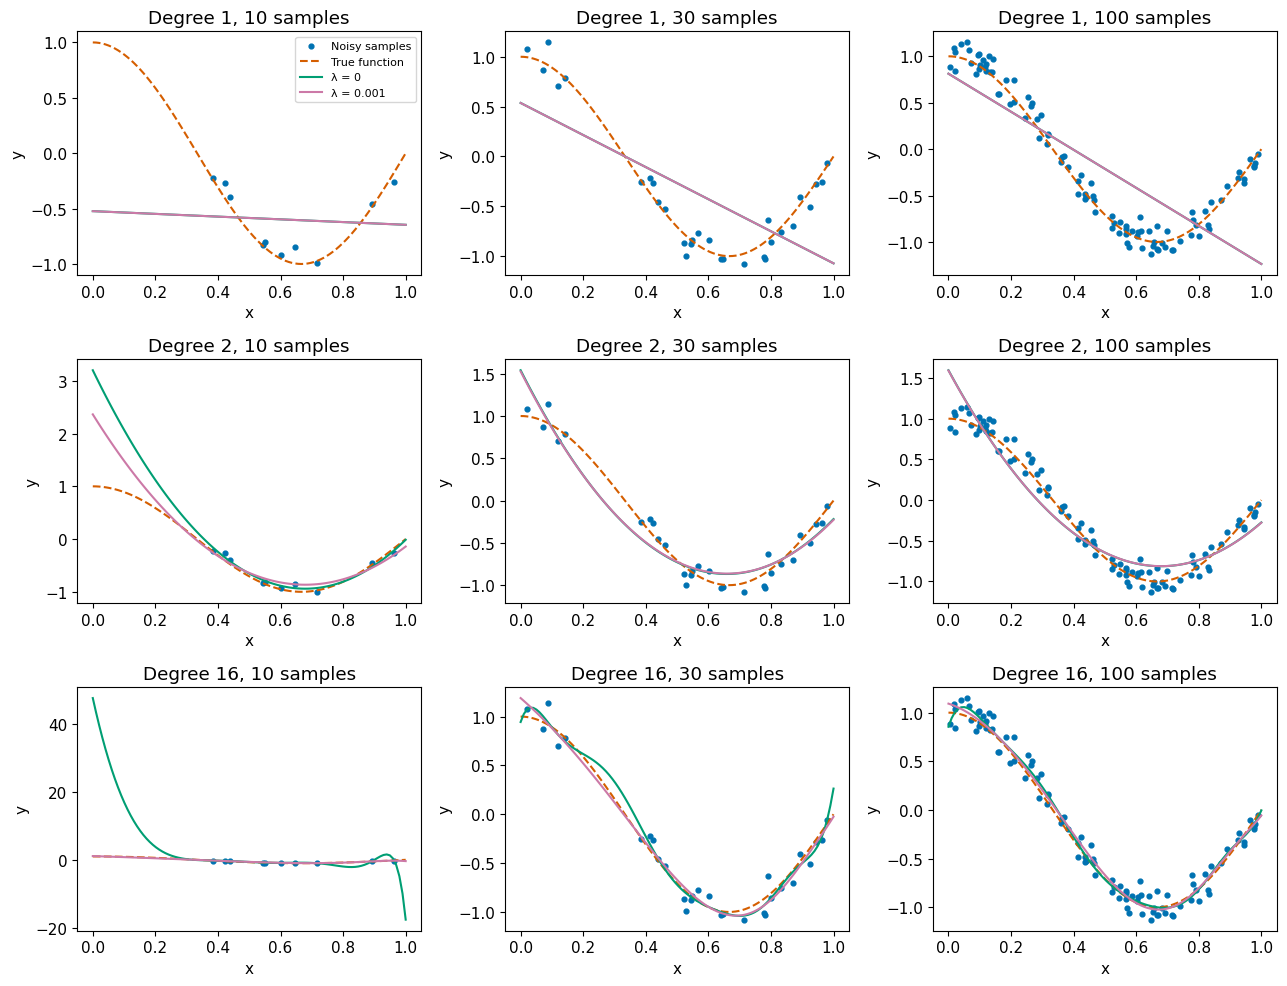

In [17]:
sample_sizes = [10, 30, 100]
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for col, n in enumerate(sample_sizes):
    sample_rng = np.random.RandomState(0)
    x_sample = np.sort(sample_rng.rand(n))
    y_sample = true_function(x_sample) + sample_rng.randn(n) * 0.1
    for row, degree in enumerate(degrees):
        ax = axes[row, col]
        ax.scatter(x_sample, y_sample, color=BLUE, s=12, label="Noisy samples")
        ax.plot(X_test, true_function(X_test), color=RED, linestyle="--", label="True function")
        for alpha, color in [(0, GREEN), (1e-3, "#CC79A7")]:
            model = fit_polynomial(x_sample, y_sample, degree, alpha)
            ax.plot(X_test, model.predict(X_test[:, np.newaxis]), color=color, label=f"λ = {alpha:g}")
        ax.set_title(f"Degree {degree}, {n} samples")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
axes[0, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

#### 2.17 Why do we need a test set in machine learning?

A test set measures how well the final model predicts samples it has not seen during fitting or model selection. Training error alone can be misleading: a flexible model may fit the training noise and still predict new samples poorly. We keep the test set separate from the start, as in the data-splitting slides, and use it for the final evaluation.

#### 2.18 If we need to optimize hyperparameters, do we use the test set to select the best hyperparameters? (1 point)

No. We choose hyperparameters such as polynomial degree and $\lambda$ using a validation set or cross-validation on the training data. In cross-validation, we fit on some folds and evaluate on the remaining fold, then average the validation scores.

After selecting the hyperparameters, we refit on the training data and evaluate the final model on the untouched test set. Selecting hyperparameters using test results would leak information into model selection and make the reported performance too optimistic.

## Course material

The matrix notation and least-squares fit follow `3_featurisation.pdf` and `5_regression.pdf`. The discussion of underfitting and overfitting follows `6_biasvariance.pdf`, and the ridge loss and closed-form solution follow `8_ridgereg.pdf`. The answers on evaluation and hyperparameters follow `4_datasplitting.pdf` and `7_hyperparams.pdf`. The discussion of correlated features is consistent with `9_interpretability.pdf`.

We retain the supplied notebook structure. In question 2.5 we correct the reversed inverse expression, and in question 2.9 we use the name Williams plot. The rank answers distinguish the stated independent-column assumption from the general case.